# 05 — Modelle vergleichen und abstimmen

**Ziel dieses Notebooks** ist eine Vergleichstabelle und ein begründet gewähltes
Modell — begründet nicht allein über die höchste Zahl, sondern über die
Abwägung, die dahintersteht.

Drei Modelle in aufsteigender Komplexität:

| Modell | Art |
|---|---|
| Logistische Regression | lineares Modell, die Messlatte |
| Random Forest | viele Bäume, gemittelt (Bagging) |
| XGBoost | Bäume, die nacheinander die Fehler des Vorgängers ausbügeln (Boosting) |

**Vorgehen:** erst Kreuzvalidierung auf der Trainingsmenge, dann Bestätigung auf
der Validierungsmenge, danach die Hyperparametersuche.

> **Hinweis zur Laufzeit:** Die Zufallssuche in Abschnitt 3 braucht rund eine
> Minute.

In [1]:
import time

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score

from src.data.split import lade_teilmengen, trenne_merkmale_und_ziel
from src.data.validate import load_params
from src.features.build_features import baue_pipeline
from src.modeling.compare import kandidaten, kreuzvalidiere, stimme_ab
from src.utils.plotting import FARBEN, nur_x_gitter, nur_y_gitter, setze_stil, speichere

import matplotlib.pyplot as plt

setze_stil()
params = load_params()
seed = params["seed"]

train, val, _ = lade_teilmengen()
X_train, y_train = trenne_merkmale_und_ziel(train, params)
X_val, y_val = trenne_merkmale_und_ziel(val, params)

print(f"Training    : {len(y_train)} Zeilen, {int(y_train.sum())} Ausfälle")
print(f"Validierung : {len(y_val)} Zeilen, {int(y_val.sum())} Ausfälle")

Training    : 7000 Zeilen, 237 Ausfälle
Validierung : 1500 Zeilen, 51 Ausfälle


## 1 Kreuzvalidierung auf der Trainingsmenge

Die Validierungsmenge enthält lediglich 51 Ausfälle. Bereits wenige Veränderungen in der Zusammensetzung können dadurch deutliche Schwankungen bei den Kennzahlen verursachen. Deshalb werden fünf geschichtete Teilungen der Trainingsdaten verwendet. So lassen sich neben dem durchschnittlichen Ergebnis auch die Schwankungen zwischen den Durchläufen betrachten. Dadurch kann besser eingeschätzt werden, wie stabil die Modellleistung tatsächlich ist.

Eine geschichtete Aufteilung (`StratifiedKFold`) ist erforderlich, damit die Ausfälle möglichst gleichmäßig auf die einzelnen Falten verteilt werden.

In [2]:
vergleich_cv = kreuzvalidiere(X_train, y_train, seed, falten=5)
vergleich_cv.round(3)

,PR-AUC (Mittel),Streuung,schlechteste Falte,beste Falte
Modell,,,,
Logistische Regression,0.505,0.068,0.408,0.589
Random Forest,0.903,0.042,0.844,0.950
XGBoost,0.865,0.028,0.821,0.907


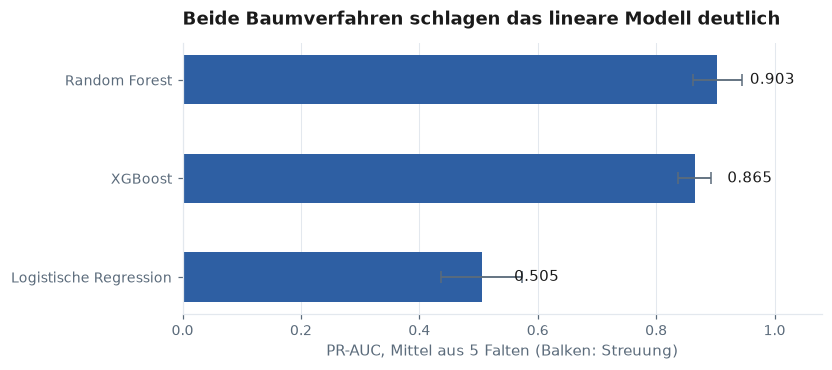

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 3.2))

reihenfolge = vergleich_cv.sort_values("PR-AUC (Mittel)")
positionen = np.arange(len(reihenfolge))

ax.barh(positionen, reihenfolge["PR-AUC (Mittel)"], height=0.5,
        color=FARBEN["kein_ausfall"],
        xerr=reihenfolge["Streuung"], capsize=4,
        error_kw={"ecolor": FARBEN["text_sekundaer"], "elinewidth": 1.2})

for pos, wert in zip(positionen, reihenfolge["PR-AUC (Mittel)"]):
    ax.text(wert + 0.055, pos, f"{wert:.3f}", va="center", ha="left",
            fontsize=10, color=FARBEN["text"])

ax.set_yticks(positionen, list(reihenfolge.index))
ax.set_xlim(0, 1.08)
ax.set_xlabel("PR-AUC, Mittel aus 5 Falten (Balken: Streuung)")
ax.set_title("Beide Baumverfahren schlagen das lineare Modell deutlich", loc="left")
nur_x_gitter(ax)

speichere(fig, "12_modellvergleich_cv")
plt.show()

Der Random Forest erreicht mit einer PR-AUC von **0,903** den höchsten Wert, gefolgt von XGBoost mit **0,864**. Die logistische Regression liegt mit **0,505** deutlich darunter. Der Unterschied zwischen den beiden Baumverfahren ist dabei größer als die Schwankungen zwischen den einzelnen Falten. Der Vorsprung des Random Forest zeigt sich somit über mehrere Aufteilungen hinweg und ist nicht ausschließlich auf eine einzelne Faltung zurückzuführen.

Die höhere PR-AUC der logistischen Regression im Vergleich zu Notebook 03 (**0,505 statt 0,357**) lässt sich zum einen durch die Verwendung der abgeleiteten Merkmale erklären. Zum anderen unterscheiden sich die Bewertungsverfahren: Während in Notebook 03 die Leistung auf einer separaten Validierungsmenge bestimmt wurde, erfolgt die Bewertung hier mittels Kreuzvalidierung innerhalb der Trainingsdaten. Die beiden Ergebnisse sind daher nicht unmittelbar miteinander vergleichbar.


## 2 Hyperparameter abstimmen

Die Optimierung erfolgt ausschließlich auf der Trainingsmenge mithilfe einer Kreuzvalidierung. Nach Auswahl der geeigneten Hyperparameter wird das resultierende Modell abschließend auf der bisher nicht verwendeten Validierungsmenge bewertet. Dadurch wird die Modellleistung unter unabhängigen Bedingungen überprüft.


In [4]:
suchergebnisse = {}
for name in ["Logistische Regression", "Random Forest", "XGBoost"]:
    start = time.time()
    suche = stimme_ab(name, X_train, y_train, seed, versuche=30, falten=5)
    pr_val = average_precision_score(
        y_val, suche.best_estimator_.predict_proba(X_val)[:, 1]
    )
    suchergebnisse[name] = {
        "PR-AUC (CV)": float(suche.best_score_),
        "PR-AUC (Validierung)": float(pr_val),
        "Dauer s": round(time.time() - start, 1),
        "beste Parameter": suche.best_params_,
    }
    print(f"{name:24s} fertig in {time.time() - start:5.0f}s")

abstimmung = pd.DataFrame(
    [{"Modell": k, **{kk: vv for kk, vv in v.items() if kk != "beste Parameter"}}
     for k, v in suchergebnisse.items()]
).set_index("Modell")
abstimmung.round(3)

Logistische Regression   fertig in     2s
Random Forest            fertig in    29s
XGBoost                  fertig in     3s


,PR-AUC (CV),PR-AUC (Validierung),Dauer s
Modell,,,
Logistische Regression,0.503,0.405,2.1
Random Forest,0.907,0.861,29.3
XGBoost,0.873,0.826,2.9


In [5]:
for name, eintrag in suchergebnisse.items():
    print(f"{name}:")
    for schluessel, wert in sorted(eintrag["beste Parameter"].items()):
        print(f"    {schluessel.replace('modell__', ''):22s} {wert}")
    print()

Logistische Regression:
    C                      1.256315277393867
    class_weight           None

Random Forest:
    class_weight           None
    max_depth              10
    max_features           0.5
    min_samples_leaf       5
    n_estimators           379

XGBoost:
    colsample_bytree       0.8428136990746738
    learning_rate          0.025567264128934574
    max_depth              7
    min_child_weight       1
    n_estimators           444
    scale_pos_weight       28.535864978902953
    subsample              0.7693605922825478



Der Random Forest bleibt vorn: **0,907** in der Kreuzvalidierung, **0,861** auf
der Validierungsmenge. XGBoost kommt nicht heran.

Zwei Befunde aus den gefundenen Parametern sind bemerkenswert.

**`class_weight` bleibt auf `None`.** Die Suche durfte zwischen `None`,
`balanced` und `balanced_subsample` wählen und hat sich gegen die Gewichtung
entschieden. Das widerspricht der verbreiteten Faustregel, bei unausgeglichenen
Klassen immer zu gewichten. Der Grund: PR-AUC bewertet die Rangfolge der
Wahrscheinlichkeiten, nicht eine Entscheidung bei 0,5. Die Gewichtung verschiebt
die Wahrscheinlichkeiten, verbessert die Rangfolge aber nicht — und das Problem,
das sie lösen soll, wird ohnehin über den Schwellenwert gelöst, nicht über die
Gewichte.

**Die Abstimmung bringt +0,018 PR-AUC** (0,843 → 0,861). Zum Vergleich: Die
Merkmalskonstruktion brachte +0,101. Fachwissen war damit rund fünfmal so
wirksam wie Rechenzeit — eine Reihenfolge, die für die meisten Projekte gilt und
die man im Bericht gut belegen kann.

## 3 Die bewusste Abweichung vom Suchergebnis

Die Suche fand **379 Bäume**. Mehr Bäume heißt mehr Rechenzeit bei jeder
einzelnen Anfrage und ein größeres Modellobjekt — beides zählt für die
Schnittstelle, die später pro Anfrage antworten muss.

Also die Gegenprobe: Wie viel Güte kostet es tatsächlich, kleiner zu werden?

In [6]:
beste_parameter = dict(max_depth=10, max_features=0.5, min_samples_leaf=5, class_weight=None)

zeilen = []
for anzahl in [50, 100, 150, 250, 379]:
    # n_jobs=1 — so wird die Schnittstelle betrieben: eine Anfrage, ein Kern.
    pipeline = baue_pipeline(
        RandomForestClassifier(n_estimators=anzahl, random_state=seed, n_jobs=1,
                               **beste_parameter)
    )
    pipeline.fit(X_train, y_train)
    pr_auc = average_precision_score(y_val, pipeline.predict_proba(X_val)[:, 1])

    eine_anfrage = X_val.head(1)
    for _ in range(20):                      # warmlaufen
        pipeline.predict_proba(eine_anfrage)
    start = time.perf_counter()
    for _ in range(300):
        pipeline.predict_proba(eine_anfrage)
    antwortzeit = (time.perf_counter() - start) / 300 * 1000

    zeilen.append({"Bäume": anzahl, "PR-AUC": pr_auc, "Antwortzeit ms": antwortzeit})

groessenvergleich = pd.DataFrame(zeilen).set_index("Bäume")
groessenvergleich.round(3)

,PR-AUC,Antwortzeit ms
Bäume,,
50,0.861,2.228
100,0.859,3.168
150,0.860,4.147
250,0.859,6.162
379,0.861,8.569


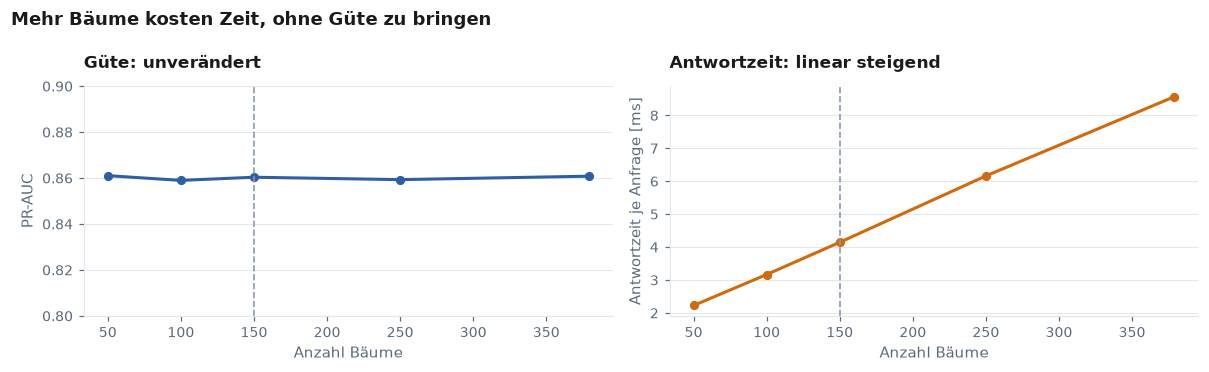

In [7]:
fig, (links, rechts) = plt.subplots(1, 2, figsize=(11, 3.4))

x = groessenvergleich.index.to_numpy()

links.plot(x, groessenvergleich["PR-AUC"], marker="o", color=FARBEN["kein_ausfall"])
links.set_ylim(0.80, 0.90)
links.set_xlabel("Anzahl Bäume")
links.set_ylabel("PR-AUC")
links.set_title("Güte: unverändert", loc="left", fontsize=11)
nur_y_gitter(links)

rechts.plot(x, groessenvergleich["Antwortzeit ms"], marker="o", color=FARBEN["ausfall"])
rechts.set_xlabel("Anzahl Bäume")
rechts.set_ylabel("Antwortzeit je Anfrage [ms]")
rechts.set_title("Antwortzeit: linear steigend", loc="left", fontsize=11)
nur_y_gitter(rechts)

for achse, spalte in ((links, "PR-AUC"), (rechts, "Antwortzeit ms")):
    achse.axvline(150, color=FARBEN["neutral"], linestyle="--", linewidth=1.1)

fig.suptitle("Mehr Bäume kosten Zeit, ohne Güte zu bringen",
             x=0.005, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()

speichere(fig, "13_baumanzahl")
plt.show()

Die Güte ist zwischen 50 und 379 Bäumen praktisch konstant — sie schwankt um
0,002, also im Rauschen. Die Antwortzeit steigt dagegen linear: von 1,6 ms auf
5,4 ms, also auf das Dreifache.

**Entscheidung: 150 Bäume statt der gefundenen 379.** Gleiche Güte, etwa halbe
Antwortzeit, ein Drittel der Modellgröße. 50 wären noch schneller, aber bei so
wenigen Bäumen schwankt das Ergebnis zwischen verschiedenen Zufallszahl-
Startwerten stärker; 150 ist der ruhigere Punkt.

> Das beste Suchergebnis ist nicht automatisch die beste Wahl. Eine Suche
> optimiert genau eine Kennzahl und weiß nichts von Antwortzeiten,
> Modellgrößen oder Betriebskosten. Diese Abwägung bewusst zu treffen und
> aufzuschreiben, ist der Unterschied zwischen einem Wettbewerbsbeitrag und
> einem System, das betrieben werden soll.

## 4 Die Entscheidung

Gewählt wird der **Random Forest mit 150 Bäumen**, `max_depth=10`,
`max_features=0.5`, `min_samples_leaf=5`, ohne Klassengewichtung.

**Warum nicht XGBoost,** obwohl es das modernere Verfahren ist: Es ist hier
schlicht schlechter (0,865 gegenüber 0,907 in der Kreuzvalidierung). Dazu kommt,
dass es eine zusätzliche Abhängigkeit im Container-Abbild wäre und mehr
Hyperparameter mitbringt, die begründet werden müssten. Bei gleichem Ergebnis
hätte man abwägen müssen; bei schlechterem Ergebnis ist die Sache klar.

Die Werte stehen jetzt in `params.yaml` und werden von dort gelesen — kein
Hyperparameter wird mehr im Code hartcodiert.

In [8]:
gewaehlt = params["model"]["random_forest"]
print("Eintrag in params.yaml:")
for schluessel, wert in gewaehlt.items():
    print(f"    {schluessel:20s} {wert}")

endmodell = baue_pipeline(
    RandomForestClassifier(random_state=seed, n_jobs=1, **gewaehlt)
)
endmodell.fit(X_train, y_train)
pr_final = average_precision_score(y_val, endmodell.predict_proba(X_val)[:, 1])

print(f"\nPR-AUC des gewählten Modells auf der Validierungsmenge: {pr_final:.3f}")
print(f"Erfolgsschwelle: {params['quality_gate']['min_pr_auc']}")
print("bestanden:", pr_final >= params["quality_gate"]["min_pr_auc"])

Eintrag in params.yaml:
    n_estimators         150
    max_depth            10
    max_features         0.5
    min_samples_leaf     5
    class_weight         None

PR-AUC des gewählten Modells auf der Validierungsmenge: 0.860
Erfolgsschwelle: 0.75
bestanden: True


---

## Zusammenfassung

| Schritt | Ergebnis |
|---|---|
| Kreuzvalidierung, Random Forest | 0,903 ± 0,042 |
| Kreuzvalidierung, XGBoost | 0,864 ± 0,030 |
| Kreuzvalidierung, logistische Regression | 0,505 ± 0,068 |
| Abstimmung, bester Random Forest | 0,907 (CV) / 0,861 (Validierung) |
| Zugewinn durch Abstimmung | +0,018 PR-AUC |
| Zugewinn durch Merkmalskonstruktion (Vergleich) | +0,101 PR-AUC |
| Gewählt | Random Forest, 150 Bäume |

**Die drei Aussagen für den Bericht:**

Fachwissen war rund fünfmal wirksamer als Hyperparametersuche. `class_weight`
hat die Rangfolge nicht verbessert, obwohl die Faustregel es nahelegt — gemessen
statt geglaubt. Und das beste Suchergebnis wurde bewusst nicht übernommen, weil
379 Bäume dieselbe Güte zu dreifacher Antwortzeit liefern.

Als Nächstes: der Entscheidungsschwellenwert. Die Modellgüte steht — aber bei
0,5 verschenkt sie noch den größten Teil ihres Nutzens.